**Load Dataset**

In [285]:
# LOAD RAW DATA
import pandas as pd
import numpy as np

# load dataset
dataset_soil = pd.read_csv('dataset_soil.csv')

# lihat data awal
print(dataset_soil.head())
len(dataset_soil)

  soil_sensor    hu    ta   ec   ph    n    p    k            timestamp
0          S1  32.6  25.7  688  4.9  111  303  297  2024-06-07 22:15:00
1          S2  45.3  24.8  378  5.5   67  202  195  2024-06-07 22:15:00
2          S3  23.3  26.1  276  5.2   25  105   98  2024-06-07 22:15:00
3          S4  22.7  25.7  271  5.0   37  133  126  2024-06-07 22:15:00
4          S1  34.0  25.7  687  4.9  111  303  297  2024-06-07 22:20:00


9014

**Timestamp to Timestep Conversion**

In [286]:
import pandas as pd

# Timestamp ke datetime
dataset_soil["timestamp"] = pd.to_datetime(dataset_soil["timestamp"])

# Urutkan berdasarkan waktu dan sensor
dataset_soil = (
    dataset_soil
    .sort_values(["timestamp", "soil_sensor"])
    .reset_index(drop=True)
)

# Mapping timestamp unik menjadi timestep
unique_timestamp = (
    dataset_soil["timestamp"]
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

timestep_map = {
    ts: i
    for i, ts in enumerate(unique_timestamp)
}

dataset_soil["timestep"] = dataset_soil["timestamp"].map(timestep_map)

dataset = dataset_soil.copy()

print(dataset.head())
print("Jumlah timestep :", dataset["timestep"].nunique())

  soil_sensor    hu    ta   ec   ph    n    p    k           timestamp  \
0          S1  32.6  25.7  688  4.9  111  303  297 2024-06-07 22:15:00   
1          S2  45.3  24.8  378  5.5   67  202  195 2024-06-07 22:15:00   
2          S3  23.3  26.1  276  5.2   25  105   98 2024-06-07 22:15:00   
3          S4  22.7  25.7  271  5.0   37  133  126 2024-06-07 22:15:00   
4          S1  34.0  25.7  687  4.9  111  303  297 2024-06-07 22:20:00   

   timestep  
0         0  
1         0  
2         0  
3         0  
4         1  
Jumlah timestep : 1414


**Missing Value Inspection**

In [287]:
# Pilih kolom numerik
numerical_cols = dataset.select_dtypes(include=['number']).columns

# Hitung jumlah nilai 0 pada setiap kolom
zero_counts = {}
for col in numerical_cols:
    count_zero = (dataset[col] == 0).sum()
    if count_zero > 0:
        zero_counts[col] = count_zero

# Tampilkan hasil
if zero_counts:
    print("Kolom-kolom berikut memiliki nilai 0 di dataset_soil.csv:")
    for col, count in zero_counts.items():
        print(f"- Kolom '{col}': {count} nilai 0")
else:
    print("Tidak ada nilai 0 yang ditemukan di kolom numerik dataset_soil.csv.")

Kolom-kolom berikut memiliki nilai 0 di dataset_soil.csv:
- Kolom 'ph': 3 nilai 0
- Kolom 'k': 3 nilai 0
- Kolom 'timestep': 4 nilai 0


**Missing Value Handling**

In [288]:
# Ganti nilai 0 menjadi NaN pada kolom ph dan k
dataset['ph'] = dataset['ph'].replace(0, np.nan)
dataset['k'] = dataset['k'].replace(0, np.nan)

# Interpolasi linear
dataset['ph'] = dataset['ph'].interpolate(method='linear', limit_direction='both')
dataset['k'] = dataset['k'].interpolate(method='linear', limit_direction='both')

# Cek apakah masih ada nilai 0
zero_counts = (dataset[['ph', 'k']] == 0).sum()
print("Jumlah nilai 0 setelah interpolasi:")
print(zero_counts)

# Cek apakah masih ada NaN
print("\nJumlah NaN setelah interpolasi:")
print(dataset[['ph', 'k']].isna().sum())

Jumlah nilai 0 setelah interpolasi:
ph    0
k     0
dtype: int64

Jumlah NaN setelah interpolasi:
ph    0
k     0
dtype: int64


**Pivot Dataset by Sensor**

In [289]:
sensor_order = ['S1', 'S2', 'S3', 'S4', 'S5', 'S6']

def pivot_parameter(dataframe, parameter):

    pivot_df = dataframe.pivot_table(
        index='timestep',
        columns='soil_sensor',
        values=parameter,
        aggfunc='first'
    )

    pivot_df = pivot_df.reindex(columns=sensor_order)

    pivot_df.columns = [
        f'{parameter}{i+1}'
        for i in range(len(sensor_order))
    ]

    pivot_df = pivot_df.reset_index()

    return pivot_df


hu_data = pivot_parameter(dataset, 'hu')
ta_data = pivot_parameter(dataset, 'ta')
ec_data = pivot_parameter(dataset, 'ec')
ph_data = pivot_parameter(dataset, 'ph')
n_data  = pivot_parameter(dataset, 'n')
p_data  = pivot_parameter(dataset, 'p')
k_data  = pivot_parameter(dataset, 'k')

print(len(hu_data))

1414


**Interpolation after Pivoting**

In [290]:
# Daftar dataframe
dataframes = {
    "HU": hu_data,
    "TA": ta_data,
    "EC": ec_data,
    "PH": ph_data,
    "N": n_data,
    "P": p_data,
    "K": k_data
}

for name, df in dataframes.items():

    print(f"\n{name}")
    print("Jumlah NaN sebelum interpolasi:")
    print(df.isna().sum())

    # Interpolasi semua kolom kecuali timestep
    cols = df.columns.drop('timestep')
    df[cols] = df[cols].interpolate(
        method='linear',
        limit_direction='both'
    )

    print("\nJumlah NaN setelah interpolasi:")
    print(df.isna().sum())


HU
Jumlah NaN sebelum interpolasi:
timestep    0
hu1         0
hu2         1
hu3         2
hu4         2
hu5         4
hu6         4
dtype: int64

Jumlah NaN setelah interpolasi:
timestep    0
hu1         0
hu2         0
hu3         0
hu4         0
hu5         0
hu6         0
dtype: int64

TA
Jumlah NaN sebelum interpolasi:
timestep    0
ta1         0
ta2         1
ta3         2
ta4         2
ta5         4
ta6         4
dtype: int64

Jumlah NaN setelah interpolasi:
timestep    0
ta1         0
ta2         0
ta3         0
ta4         0
ta5         0
ta6         0
dtype: int64

EC
Jumlah NaN sebelum interpolasi:
timestep    0
ec1         0
ec2         1
ec3         2
ec4         2
ec5         4
ec6         4
dtype: int64

Jumlah NaN setelah interpolasi:
timestep    0
ec1         0
ec2         0
ec3         0
ec4         0
ec5         0
ec6         0
dtype: int64

PH
Jumlah NaN sebelum interpolasi:
timestep    0
ph1         0
ph2         1
ph3         2
ph4         2
ph5         4
ph6    

**Data Normalization**

In [291]:
from sklearn.preprocessing import MinMaxScaler

def normalize_data(df):

    timestep = df['timestep']

    X = df.drop(columns=['timestep'])

    scaler = MinMaxScaler()

    X_scaled = scaler.fit_transform(X)

    return X_scaled, scaler, timestep


# HU
hu_X, hu_scaler, hu_ts = normalize_data(hu_data)

# TA
ta_X, ta_scaler, ta_ts = normalize_data(ta_data)

# EC
ec_X, ec_scaler, ec_ts = normalize_data(ec_data)

# PH
ph_X, ph_scaler, ph_ts = normalize_data(ph_data)

# N
n_X, n_scaler, n_ts = normalize_data(n_data)

# P
p_X, p_scaler, p_ts = normalize_data(p_data)

# K
k_X, k_scaler, k_ts = normalize_data(k_data)

print("Normalisasi selesai!")

Normalisasi selesai!


**Normalized Data Visualization**

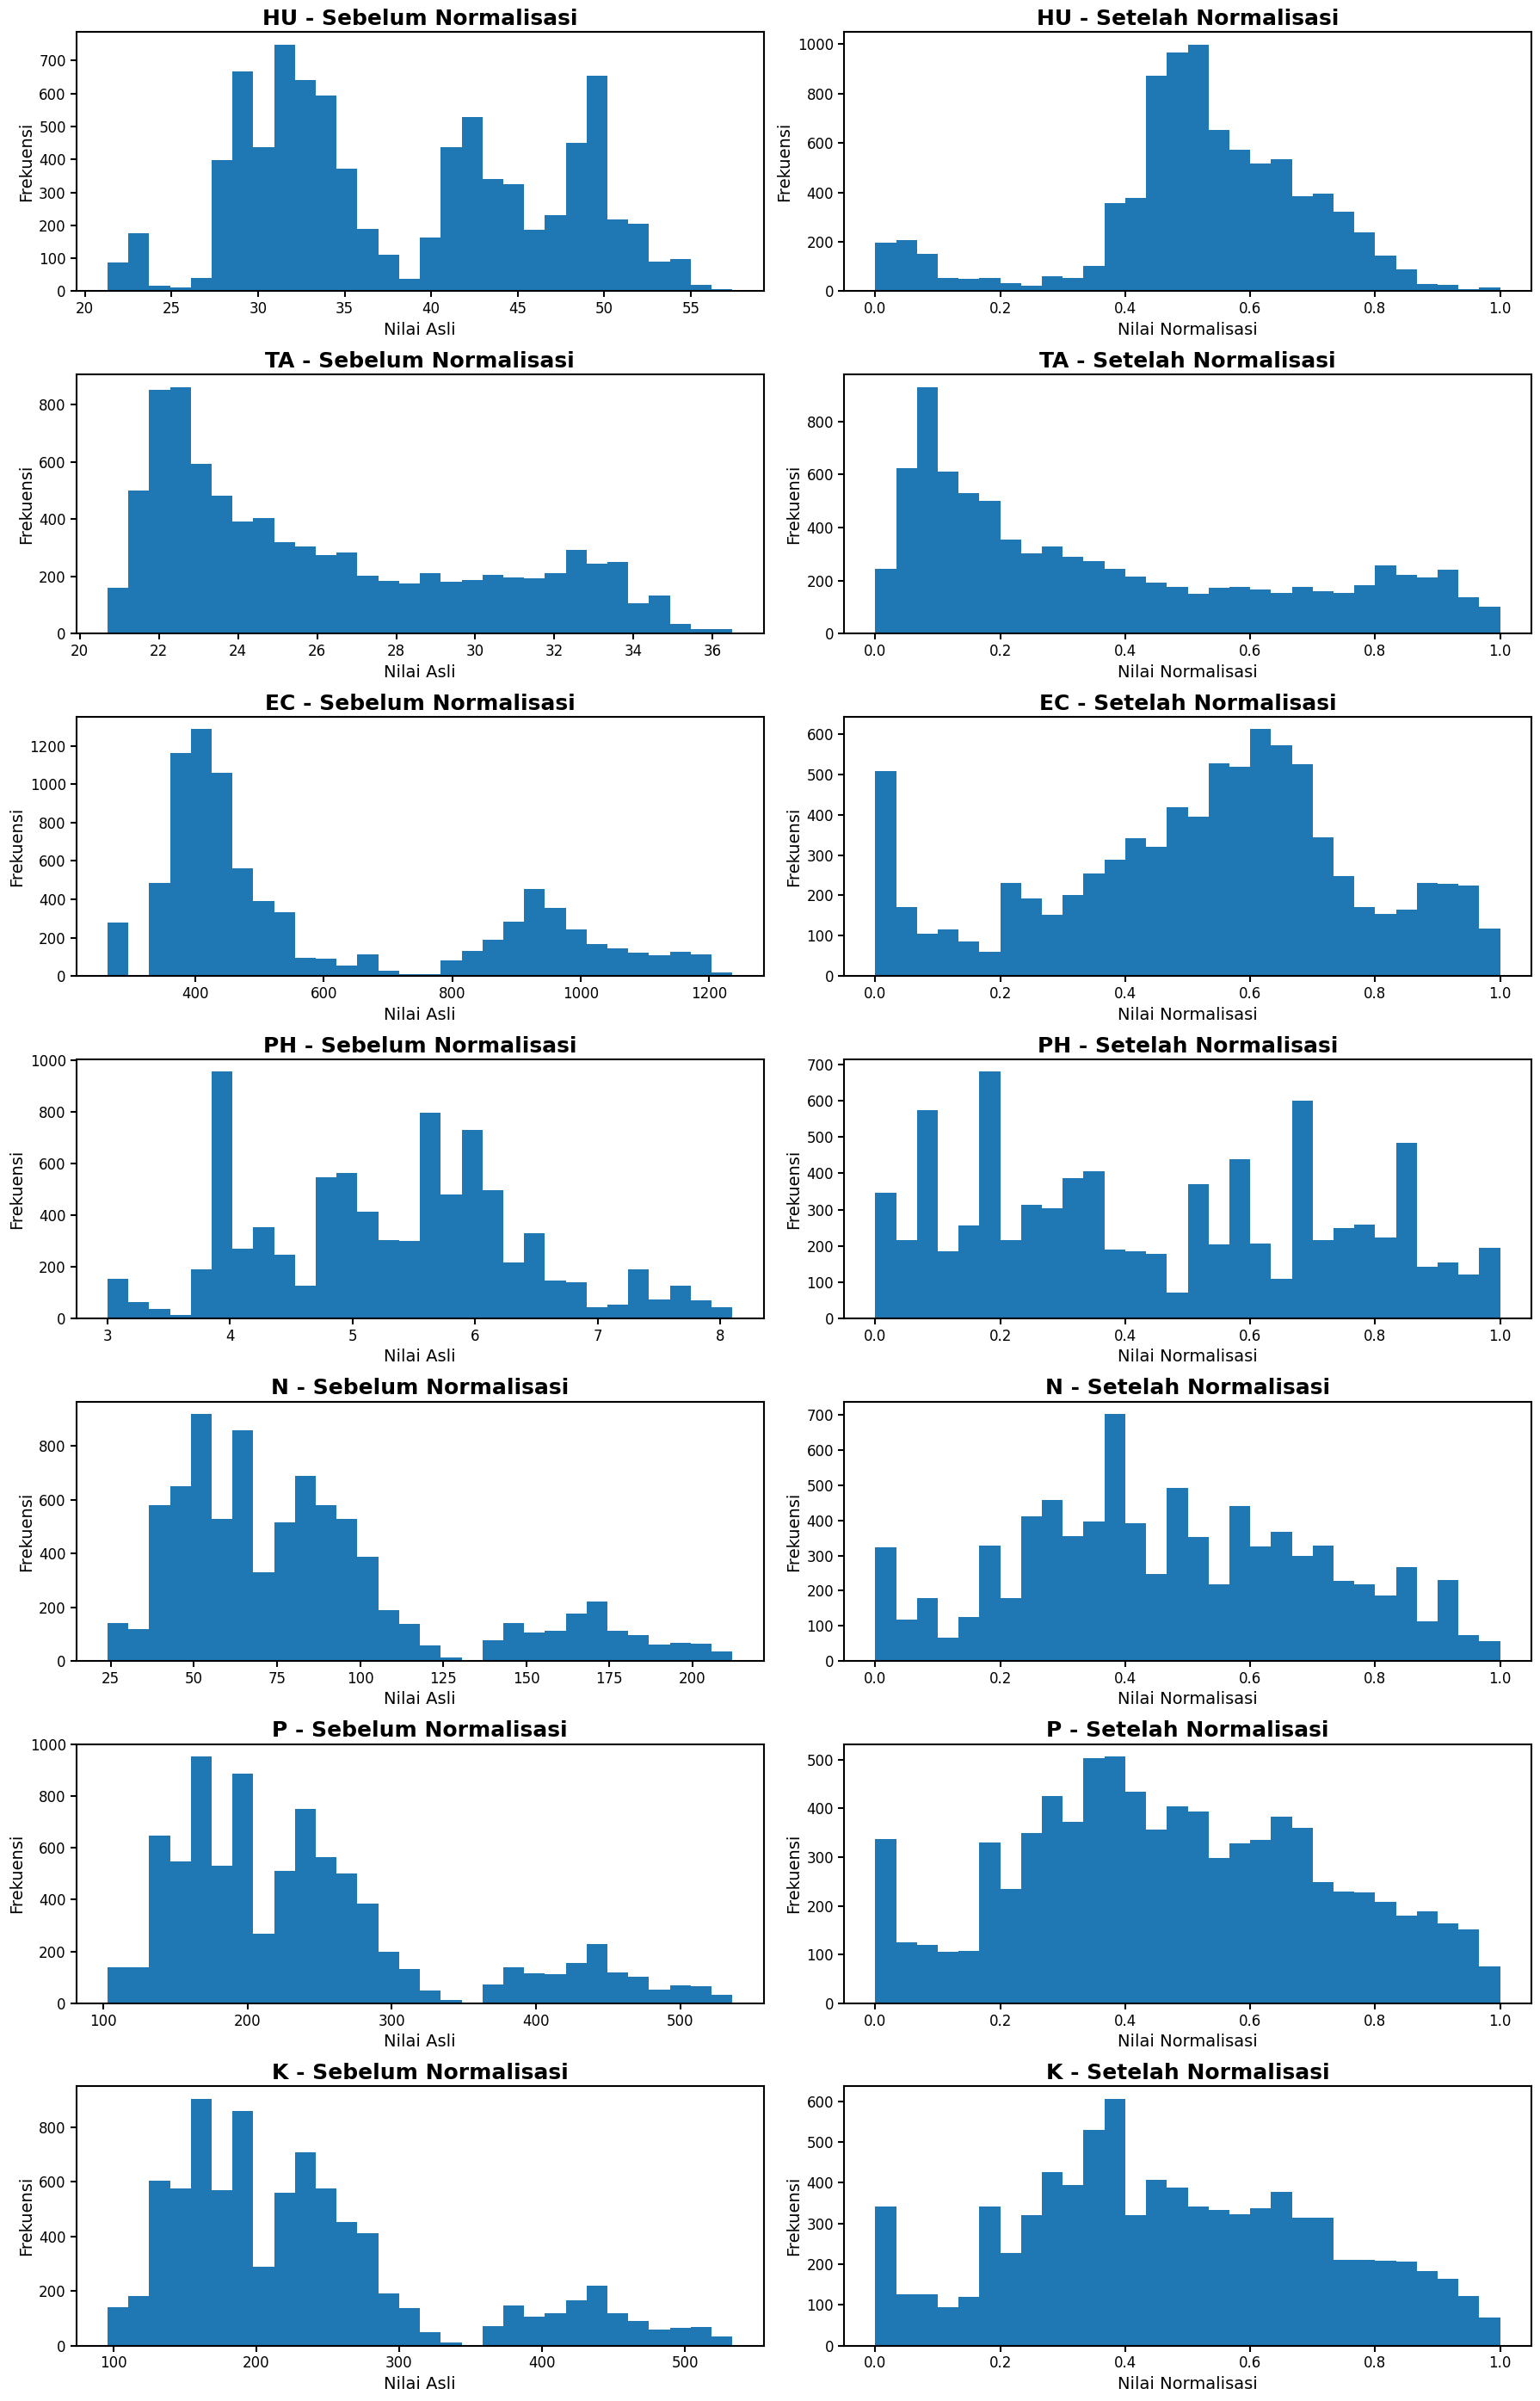

In [292]:
import matplotlib.pyplot as plt

# Data sebelum normalisasi
before_data = [
    hu_data.drop(columns=['timestep']).values,
    ta_data.drop(columns=['timestep']).values,
    ec_data.drop(columns=['timestep']).values,
    ph_data.drop(columns=['timestep']).values,
    n_data.drop(columns=['timestep']).values,
    p_data.drop(columns=['timestep']).values,
    k_data.drop(columns=['timestep']).values
]

# Data setelah normalisasi
after_data = [
    hu_X,
    ta_X,
    ec_X,
    ph_X,
    n_X,
    p_X,
    k_X
]

# Nama parameter
titles = ['HU', 'TA', 'EC', 'PH', 'N', 'P', 'K']

# Membuat subplot 7 baris × 2 kolom
fig, axes = plt.subplots(7, 2, figsize=(18, 28))

# Menampilkan histogram sebelum dan sesudah normalisasi
for i in range(len(titles)):

    # Histogram sebelum normalisasi
    axes[i, 0].hist(before_data[i].flatten(), bins=30)

    axes[i, 0].set_title(
        f'{titles[i]} - Sebelum Normalisasi',
        fontsize=18,
        fontweight='bold'
    )

    axes[i, 0].set_xlabel('Nilai Asli', fontsize=14)
    axes[i, 0].set_ylabel('Frekuensi', fontsize=14)

    axes[i, 0].tick_params(
        axis='both',
        labelsize=12,
        width=1.5,
        length=5
    )

    for spine in axes[i, 0].spines.values():
        spine.set_linewidth(1.5)

    # Histogram setelah normalisasi
    axes[i, 1].hist(after_data[i].flatten(), bins=30)

    axes[i, 1].set_title(
        f'{titles[i]} - Setelah Normalisasi',
        fontsize=18,
        fontweight='bold'
    )

    axes[i, 1].set_xlabel('Nilai Normalisasi', fontsize=14)
    axes[i, 1].set_ylabel('Frekuensi', fontsize=14)

    axes[i, 1].tick_params(
        axis='both',
        labelsize=12,
        width=1.5,
        length=5
    )

    for spine in axes[i, 1].spines.values():
        spine.set_linewidth(1.5)

# Mengatur jarak antar subplot
plt.tight_layout()

# Menyimpan gambar dengan resolusi tinggi
plt.savefig(
    "perbandingan_distribusi_sebelum_dan_setelah_normalisasi.png",
    dpi=600,
    bbox_inches="tight"
)

# Menampilkan visualisasi
plt.show()

**Autoencoder Model Construction and Autoencoder Training**

In [293]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np # Import numpy for isnan check
import pandas as pd # Import pandas for DataFrame operations


# FUNCTION AUTOENCODER
def build_autoencoder(input_dim):

    # input
    input_layer = Input(shape=(input_dim,))

    # encoder
    encoder = Dense(4, activation='relu')(input_layer)
    encoder = Dense(2, activation='relu')(encoder)

    # decoder
    # The output dimension of the decoder should match the input_dim
    decoder = Dense(4, activation='relu')(encoder)
    decoder = Dense(input_dim, activation='sigmoid')(decoder) # Changed from 6 to input_dim

    # model
    autoencoder = Model(inputs=input_layer, outputs=decoder)

    autoencoder.compile(
        optimizer='adam',
        loss='mse'
    )

    return autoencoder


# FUNCTION TRAINING
def train_autoencoder(X_train_raw):

    # Convert to DataFrame to easily handle NaN columns
    X_train_df = pd.DataFrame(X_train_raw)

    # Drop columns that contain any NaN values
    # This addresses the issue of non-existent sensor data
    X_train_df = X_train_df.dropna(axis=1)

    # Convert back to numpy array
    X_train = X_train_df.values

    # Check if X_train is empty after dropping NaNs
    if X_train.shape[1] == 0:
        print("Warning: All features contain NaN values. Autoencoder cannot be trained.")
        # Return None for model and history, which will propagate NaNs later
        return None, None


    input_dim = X_train.shape[1]

    model = build_autoencoder(input_dim)

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

    history = model.fit(
        X_train, # Input data
        X_train, # Target data (for autoencoder, input == target)
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        shuffle=True,
        callbacks=[early_stop],
        verbose=1
    )

    return model, history


# TRAIN AUTOENCODER SEMUA PARAMETER
# HU
hu_ae, hu_history = train_autoencoder(hu_X)
if hu_ae is None: print("HU autoencoder not trained due to NaN issues.")

# TA
ta_ae, ta_history = train_autoencoder(ta_X)
if ta_ae is None: print("TA autoencoder not trained due to NaN issues.")

# EC
ec_ae, ec_history = train_autoencoder(ec_X)
if ec_ae is None: print("EC autoencoder not trained due to NaN issues.")

# PH
ph_ae, ph_history = train_autoencoder(ph_X)
if ph_ae is None: print("PH autoencoder not trained due to NaN issues.")

# N
n_ae, n_history = train_autoencoder(n_X)
if n_ae is None: print("N autoencoder not trained due to NaN issues.")

# P
p_ae, p_history = train_autoencoder(p_X)
if p_ae is None: print("P autoencoder not trained due to NaN issues.")

# K
k_ae, k_history = train_autoencoder(k_X)
if k_ae is None: print("K autoencoder not trained due to NaN issues.")

print("Training Autoencoder selesai!")

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0386 - val_loss: 0.0136
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0374 - val_loss: 0.0134
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0356 - val_loss: 0.0129
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0329 - val_loss: 0.0124
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0298 - val_loss: 0.0119
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0261 - val_loss: 0.0112
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0225 - val_loss: 0.0105
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0194 - val_loss: 0.0099
Epoch 9/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0171 - val_loss: 0.0094
Epoch 10/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0153 - val_loss: 0.0091
Epoch 11/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0140 - val_loss: 0.0085
Epoch 12/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0

**Data Reconstruction and Reconstruction Error Calculation**

In [294]:
import numpy as np
import pandas as pd

# FUNCTION RECONSTRUCTION
def reconstruction(model, X_raw_normalized):
    # If the model couldn't be trained (e.g., all features were NaN), return NaNs
    if model is None:
        return np.full_like(X_raw_normalized, np.nan)

    # Get the expected input dimension from the trained model
    expected_input_dim = model.input_shape[1]

    # Convert to DataFrame to easily handle columns and NaNs
    X_df = pd.DataFrame(X_raw_normalized)

    # Identify columns that were *not* dropped during training (i.e., those without NaNs)
    # This replicates the `dropna(axis=1)` logic from `train_autoencoder`
    non_nan_cols = X_df.columns[~X_df.isnull().any()].tolist()

    # Select only the non-NaN columns for prediction
    X_to_predict = X_df[non_nan_cols].values

    # Ensure the dimensions match before prediction
    if X_to_predict.shape[1] != expected_input_dim:
        # This should ideally not happen if `train_autoencoder` and `reconstruction`
        # apply consistent cleaning on consistent data.
        # If it does, it implies a deeper issue with data consistency or logic.
        print(f"Warning: Input dimensions ({X_to_predict.shape[1]}) for prediction do not match model's expected dimensions ({expected_input_dim}). This may indicate an inconsistent NaN pattern.")
        # In a robust system, this might require more complex handling or error reporting.
        # For now, we proceed assuming `X_to_predict` is the best available input.

    X_recon_processed = model.predict(X_to_predict)

    # Create a DataFrame for the full reconstructed output, initialized with NaNs
    X_recon_full_df = pd.DataFrame(np.nan, index=X_df.index, columns=X_df.columns)

    # Place the reconstructed values back into their original, non-NaN column positions
    X_recon_full_df[non_nan_cols] = X_recon_processed

    return X_recon_full_df.values


# RECONSTRUCTION SEMUA PARAMETER
hu_recon = reconstruction(hu_ae, hu_X)
ta_recon = reconstruction(ta_ae, ta_X)
ec_recon = reconstruction(ec_ae, ec_X)
ph_recon = reconstruction(ph_ae, ph_X)
n_recon  = reconstruction(n_ae, n_X)
p_recon  = reconstruction(p_ae, p_X)
k_recon  = reconstruction(k_ae, k_X)

print("Reconstruction selesai!")

# FUNCTION ERROR
def calculate_error(X, X_recon):
    # Calculate error only for non-NaN values, as NaN positions represent missing sensors
    # The error for NaN positions should also be NaN to avoid propagating incorrect values

    # Create a mask for valid (non-NaN) data points in the original input X
    valid_mask = ~np.isnan(X)

    # Initialize error array with NaNs, matching the shape of X
    error = np.full_like(X, np.nan)

    # Calculate squared error only where data is valid
    error[valid_mask] = np.square(X[valid_mask] - X_recon[valid_mask])

    return error


# ERROR SEMUA PARAMETER
hu_error = calculate_error(hu_X, hu_recon)
ta_error = calculate_error(ta_X, ta_recon)
ec_error = calculate_error(ec_X, ec_recon)
ph_error = calculate_error(ph_X, ph_recon)
n_error  = calculate_error(n_X, n_recon)
p_error  = calculate_error(p_X, p_recon)
k_error  = calculate_error(k_X, k_recon)

print("Reconstruction error selesai!")

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Reconstruction selesai!
Reconstruction error selesai!


**Threshold Determination**

In [316]:
# FUNCTION THRESHOLD
def calculate_threshold(error):
    return np.nanpercentile(error, 90, axis=0)

hu_threshold = calculate_threshold(hu_error)
ta_threshold = calculate_threshold(ta_error)
ec_threshold = calculate_threshold(ec_error)
ph_threshold = calculate_threshold(ph_error)
n_threshold = calculate_threshold(n_error)
p_threshold = calculate_threshold(p_error)
k_threshold = calculate_threshold(k_error)

print("HU Threshold :", hu_threshold)
print("TA Threshold :", ta_threshold)
print("EC Threshold :", ec_threshold)
print("PH Threshold :", ph_threshold)
print("N Threshold  :", n_threshold)
print("P Threshold  :", p_threshold)
print("K Threshold  :", k_threshold)

HU Threshold : [0.01076016 0.01717328 0.00842387 0.01026651 0.01063013 0.01106657]
TA Threshold : [0.00717118 0.01597257 0.01003591 0.00940602 0.00823311 0.00820901]
EC Threshold : [0.02053507 0.0463358  0.01578109 0.02071098 0.1206383  0.01091116]
PH Threshold : [0.23306487 0.18509469 0.19821801 0.24026479 0.18469501 0.2143944 ]
N Threshold  : [0.03701019 0.01742905 0.05431001 0.01220653 0.27675988 0.01832417]
P Threshold  : [0.0281291  0.02574193 0.05416083 0.01210763 0.13335018 0.0191853 ]
K Threshold  : [0.08767724 0.20734172 0.27818051 0.17497232 0.18131134 0.2125739 ]


**Anomaly Labeling**

In [317]:
import numpy as np
import pandas as pd

threshold_dict = {
    'HU': hu_threshold,
    'TA': ta_threshold,
    'EC': ec_threshold,
    'PH': ph_threshold,
    'N': n_threshold,
    'P': p_threshold,
    'K': k_threshold
}

error_dict = {
    'HU': hu_error,
    'TA': ta_error,
    'EC': ec_error,
    'PH': ph_error,
    'N': n_error,
    'P': p_error,
    'K': k_error
}

results = []

for param in threshold_dict.keys():

    threshold = threshold_dict[param]
    error = error_dict[param]

    # label tiap sensor
    anomaly = error > threshold

    anomaly_count = anomaly.sum()
    anomaly_percent = anomaly_count / anomaly.size * 100

    results.append([
        param,
        np.mean(threshold),          # threshold rata-rata
        anomaly_count,
        anomaly_percent
    ])

threshold_table = pd.DataFrame(
    results,
    columns=[
        "Parameter",
        "Threshold",
        "Anomaly Count",
        "Anomaly (%)"
    ]
)

threshold_table["Threshold"] = threshold_table["Threshold"].round(6)
threshold_table["Anomaly (%)"] = threshold_table["Anomaly (%)"].round(2)

print(threshold_table)

  Parameter  Threshold  Anomaly Count  Anomaly (%)
0        HU   0.011387            421         4.96
1        TA   0.009838            419         4.94
2        EC   0.039152            421         4.96
3        PH   0.209289            420         4.95
4         N   0.069340            340         4.01
5         P   0.045446            404         4.76
6         K   0.190343            383         4.51


**Labeling Result Generation**

In [318]:
# FUNCTION LABELING
def create_label(error, threshold):

    labels = (error > threshold).astype(int)

    return labels

    # LABEL SEMUA PARAMETER
hu_label = create_label(
    hu_error,
    hu_threshold
)

ta_label = create_label(
    ta_error,
    ta_threshold
)

ec_label = create_label(
    ec_error,
    ec_threshold
)

ph_label = create_label(
    ph_error,
    ph_threshold
)

n_label = create_label(
    n_error,
    n_threshold
)

p_label = create_label(
    p_error,
    p_threshold
)

k_label = create_label(
    k_error,
    k_threshold
)

print("Labeling selesai!")

Labeling selesai!


In [319]:
import pandas as pd

# Dictionary label seluruh parameter
label_dict = {
    'hu': hu_label,
    'ta': ta_label,
    'ec': ec_label,
    'ph': ph_label,
    'n': n_label,
    'p': p_label,
    'k': k_label
}

# Menampilkan label setiap parameter
for param, labels in label_dict.items():

    label_df = pd.DataFrame(
        labels,
        columns=[f'{param}{i}' for i in range(1, 7)]
    )

    print(f"{param.upper()} LABEL")
    print(label_df.head())

HU LABEL
   hu1  hu2  hu3  hu4  hu5  hu6
0    0    0    0    0    0    0
1    0    0    0    0    0    0
2    0    0    0    0    0    0
3    0    0    0    0    0    0
4    0    0    0    0    0    0
TA LABEL
   ta1  ta2  ta3  ta4  ta5  ta6
0    0    0    0    0    0    0
1    0    0    0    0    0    0
2    0    0    0    0    0    0
3    0    0    0    0    0    0
4    0    0    0    0    0    0
EC LABEL
   ec1  ec2  ec3  ec4  ec5  ec6
0    0    0    0    0    0    0
1    0    0    0    0    0    0
2    0    0    0    0    0    0
3    0    0    0    0    0    0
4    0    0    0    0    0    0
PH LABEL
   ph1  ph2  ph3  ph4  ph5  ph6
0    1    1    0    0    0    0
1    1    1    0    0    0    0
2    1    1    0    0    0    0
3    1    1    0    0    0    0
4    1    1    0    0    0    0
N LABEL
   n1  n2  n3  n4  n5  n6
0   1   0   0   0   1   0
1   1   0   0   0   1   0
2   1   0   0   0   1   0
3   1   0   0   0   1   0
4   1   0   0   0   1   0
P LABEL
   p1  p2  p3  p4  p5  p

**Sensor-wise Label Organization**

In [320]:
import pandas as pd

sensor_label = {}

for i in range(6):

    sensor_df = pd.DataFrame({
        'hu': hu_label[:, i],
        'ta': ta_label[:, i],
        'ec': ec_label[:, i],
        'ph': ph_label[:, i],
        'n':  n_label[:, i],
        'p':  p_label[:, i],
        'k':  k_label[:, i]
    })

    sensor_label[f'S{i+1}'] = sensor_df

    print(f"\nSENSOR {i+1}")
    print(sensor_df.head())


SENSOR 1
   hu  ta  ec  ph  n  p  k
0   0   0   0   1  1  1  0
1   0   0   0   1  1  1  0
2   0   0   0   1  1  1  0
3   0   0   0   1  1  1  0
4   0   0   0   1  1  1  0

SENSOR 2
   hu  ta  ec  ph  n  p  k
0   0   0   0   1  0  0  0
1   0   0   0   1  0  0  0
2   0   0   0   1  0  0  0
3   0   0   0   1  0  0  0
4   0   0   0   1  0  0  0

SENSOR 3
   hu  ta  ec  ph  n  p  k
0   0   0   0   0  0  0  0
1   0   0   0   0  0  0  0
2   0   0   0   0  0  0  0
3   0   0   0   0  0  0  0
4   0   0   0   0  0  0  0

SENSOR 4
   hu  ta  ec  ph  n  p  k
0   0   0   0   0  0  0  0
1   0   0   0   0  0  0  0
2   0   0   0   0  0  0  0
3   0   0   0   0  0  0  0
4   0   0   0   0  0  0  0

SENSOR 5
   hu  ta  ec  ph  n  p  k
0   0   0   0   0  1  1  1
1   0   0   0   0  1  1  1
2   0   0   0   0  1  1  1
3   0   0   0   0  1  1  1
4   0   0   0   0  1  1  1

SENSOR 6
   hu  ta  ec  ph  n  p  k
0   0   0   0   0  0  0  0
1   0   0   0   0  0  0  0
2   0   0   0   0  0  0  0
3   0   0   0   0  0  

**Majority Voting**

In [321]:
import pandas as pd

sensor_vote = {}
all_sensor_results = []

# Get the common number of timesteps from hu_ts
num_timesteps = len(hu_ts)

for i in range(6):

    sensor_name = f"S{i+1}"

    df_labels = sensor_label[sensor_name].copy()

    # Ensure df_labels has the same number of rows as hu_ts
    # If df_labels has more rows, truncate it. If less, this might indicate another issue.
    if len(df_labels) > num_timesteps:
        df_labels = df_labels.iloc[:num_timesteps]
    elif len(df_labels) < num_timesteps:
        # This case implies a bigger problem, but given the current error,
        # df_labels is likely longer.
        print(f"Warning: df_labels for {sensor_name} has fewer rows ({len(df_labels)}) than hu_ts ({num_timesteps}).")

    # tambahkan timestep
    df_labels.insert(0, "timestep", hu_ts.values)

    # tambahkan sensor
    df_labels.insert(1, "soil_sensor", sensor_name)

    # parameter yang digunakan voting
    label_columns = [
        "hu",
        "ta",
        "ec",
        "ph",
        "n",
        "p",
        "k"
    ]

    # jumlah vote anomaly
    df_labels["anomaly_vote_count"] = (
        df_labels[label_columns].sum(axis=1)
    )

    # majority voting
    df_labels["final_label"] = (
        df_labels["anomaly_vote_count"] >= 4
    ).astype(int)

    df_labels["final_status"] = df_labels["final_label"].map({
        0: "normal",
        1: "anomaly"
    })

    sensor_vote[sensor_name] = df_labels
    all_sensor_results.append(df_labels)

# Gabungkan seluruh sensor
all_sensor_results = pd.concat(
    all_sensor_results,
    ignore_index=True
)

print(all_sensor_results.head())

print("\nJumlah data :", len(all_sensor_results))

print("\nDistribusi label")
print(all_sensor_results["final_status"].value_counts())

   timestep soil_sensor  hu  ta  ec  ph  n  p  k  anomaly_vote_count  \
0         0          S1   0   0   0   1  1  1  0                   3   
1         1          S1   0   0   0   1  1  1  0                   3   
2         2          S1   0   0   0   1  1  1  0                   3   
3         3          S1   0   0   0   1  1  1  0                   3   
4         4          S1   0   0   0   1  1  1  0                   3   

   final_label final_status  
0            0       normal  
1            0       normal  
2            0       normal  
3            0       normal  
4            0       normal  

Jumlah data : 8484

Distribusi label
final_status
normal     8430
anomaly      54
Name: count, dtype: int64


**Export Detection Results**

In [322]:
import pandas as pd

classifier_list = []

sensor_order = ['S1', 'S2', 'S3', 'S4', 'S5', 'S6']

for i, sensor in enumerate(sensor_order, start=1):

    temp = pd.DataFrame({
        "timestep": hu_data["timestep"],
        "soil_sensor": sensor,

        "hu": hu_data[f"hu{i}"],
        "ta": ta_data[f"ta{i}"],
        "ec": ec_data[f"ec{i}"],
        "ph": ph_data[f"ph{i}"],
        "n":  n_data[f"n{i}"],
        "p":  p_data[f"p{i}"],
        "k":  k_data[f"k{i}"]
    })

    classifier_list.append(temp)

# Gabungkan seluruh sensor
classifier_df = pd.concat(
    classifier_list,
    ignore_index=True
)

In [323]:
classifier_df = classifier_df.merge(
    all_sensor_results[
        ["timestep", "soil_sensor", "final_label"]
    ],
    on=["timestep", "soil_sensor"],
    how="left"
)

classifier_df.rename(
    columns={"final_label": "label"},
    inplace=True
)

In [324]:
# Distribusi label
print(classifier_df["label"].value_counts())

# Simpan dataset classifier
classifier_df.to_csv(
    "classifier_p90_labels.csv",
    index=False
)

print("File berhasil disimpan")
print(f"Jumlah data: {len(classifier_df)}")

label
0    8430
1      54
Name: count, dtype: int64
File berhasil disimpan
Jumlah data: 8484


**Export Processed Data**

In [325]:
import pandas as pd
import numpy as np

# Install xlsxwriter if not already installed
!pip install xlsxwriter

# Create an Excel writer object
excel_file_path = 'all_processed_data_P90.xlsx'
writer = pd.ExcelWriter(excel_file_path, engine='xlsxwriter')

# Sheet 1: Raw Data (dataset)
dataset.to_excel(writer, sheet_name='Raw Data', index=False)

# Sheet 2: Normalized Data
# Initialize with timestep
combined_normalized_df = pd.DataFrame({'timestep': hu_ts})

parameter_data_X = {
    'hu': hu_X,
    'ta': ta_X,
    'ec': ec_X,
    'ph': ph_X,
    'n': n_X,
    'p': p_X,
    'k': k_X
}

for param_name, data_array in parameter_data_X.items():
    if data_array is not None:
        for i in range(data_array.shape[1]):
            combined_normalized_df[f'{param_name}{i+1}_norm'] = data_array[:, i]
combined_normalized_df.to_excel(writer, sheet_name='Normalized Data', index=False)


# Sheet 3: Reconstruction Data
combined_recon_df = pd.DataFrame({'timestep': hu_ts})

parameter_data_recon = {
    'hu': hu_recon,
    'ta': ta_recon,
    'ec': ec_recon,
    'ph': ph_recon,
    'n': n_recon,
    'p': p_recon,
    'k': k_recon
}

for param_name, data_array in parameter_data_recon.items():
    if data_array is not None:
        for i in range(data_array.shape[1]):
            combined_recon_df[f'{param_name}{i+1}_recon'] = data_array[:, i]
combined_recon_df.to_excel(writer, sheet_name='Reconstruction Data', index=False)


# Sheet 4: Reconstruction Error Data
combined_error_df = pd.DataFrame({'timestep': hu_ts})

parameter_data_error = {
    'hu': hu_error,
    'ta': ta_error,
    'ec': ec_error,
    'ph': ph_error,
    'n': n_error,
    'p': p_error,
    'k': k_error
}

for param_name, data_array in parameter_data_error.items():
    if data_array is not None:
        for i in range(data_array.shape[1]):
            combined_error_df[f'{param_name}{i+1}_error'] = data_array[:, i]
combined_error_df.to_excel(writer, sheet_name='Reconstruction Error', index=False)


# Sheet 5: Labeling Summary
threshold_table.to_excel(writer, sheet_name='Labeling Summary', index=False)

# Sheet 6: Majority Voting & Individual Labels
train_vote_df.to_excel(writer, sheet_name='Majority Voting', index=False)

# Sheet 7: Raw Data with Final Labels
classifier_df.to_excel(writer, sheet_name='Raw Data + Final Labels', index=False)

# Save the Excel file
writer.close()

print(f"All data successfully saved to {excel_file_path}")

All data successfully saved to all_processed_data_P95.xlsx
